#  Imports and Load Data

In [ ]:
# Core Data Processing
import pandas as pd
import numpy as np
import os
import re
import datetime
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Embeddings
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Environment Setup
load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

# Bring in all data from Supabase
print("Bringing data from Supabase...")
df = pd.read_sql("SELECT * FROM cars WHERE price >= 1000", engine)

# Initial NA handling for known scraped fields
df['condition'] = df['condition'].fillna('unspecified')
df['title_status'] = df['title_status'].fillna('unspecified')

print(f"Total records brought in: {len(df)}")
df.head()

/Users/abhinav/Documents/AutoValuate/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df.sample(10)

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim,region
3180,2006 Infiniti G35 ( Low Mile ) 66K 1-Owner Ve...,https://www.craigslist.org/view/d/campbell-200...,9300,70000.0,campbell,NaN,2006,NaN,20,NaN,NaN,unspecified,unspecified,NaN,NaN
1771,2009 Nissan Altima,https://www.craigslist.org/view/d/gig-harbor-2...,5200,145000.0,gig harbor,NaN,2009,NaN,17,NaN,NaN,unspecified,unspecified,NaN,NaN
685,2004 Dodge Ram 1500 Hemi – Only 53K Miles – Br...,https://www.craigslist.org/view/d/dublin-2004-...,11000,53000.0,dublin,NaN,2004,NaN,22,NaN,NaN,unspecified,unspecified,NaN,NaN
15462,2013 Toyota Scion Tc,https://www.craigslist.org/view/d/vallejo-2013...,4700,125000.0,vallejo,NaN,2013,NaN,13,7928.40,3228.400879,unspecified,unspecified,NaN,sfbay
15819,"2009 Toyota Prius Hybrid, 178K Mile Runs Great...",https://www.craigslist.org/view/d/los-angeles-...,3600,178000.0,los angeles,NaN,2009,NaN,17,4668.75,1068.749512,excellent,clean,NaN,losangeles
5856,1987 Chevrolet Caprice V8 Auto White Vinyl Top,https://www.craigslist.org/view/d/westmont-198...,14995,70000.0,downers grove,NaN,1987,NaN,39,9903.05,-5091.945312,excellent,clean,NaN,other
2923,2011 Vw Jetta Se 2.5L,https://www.craigslist.org/view/d/glendale-201...,5495,153000.0,west valley,NaN,2011,NaN,15,NaN,NaN,unspecified,unspecified,NaN,NaN
7266,2003 Jeep Sport,https://www.craigslist.org/view/d/miami-2003-j...,4200,252000.0,miami,NaN,2003,NaN,23,2782.14,-1417.860352,good,rebuilt,NaN,miami
2927,2022 Chevy Chevrolet Silverado Z71 Trail Boss,https://www.craigslist.org/view/d/glendale-202...,29900,59000.0,phoenix,NaN,2022,NaN,4,NaN,NaN,unspecified,unspecified,NaN,NaN
15677,2016 Toyota Camry Se,https://www.craigslist.org/view/d/north-hollyw...,10850,169.0,sherman oaks,NaN,2016,NaN,10,9694.71,-1155.285156,unspecified,unspecified,NaN,other


In [ ]:
df.describe()

,price,mileage,year,age,predicted_price,difference
count,18186.000000,18186.000000,18186.000000,18186.000000,15201.000000,15201.000000
mean,10635.192566,127176.773177,2008.561806,17.438194,10409.783614,-349.215279
std,10693.772297,59740.469187,12.595169,12.595169,8119.253269,6079.849118
min,800.000000,100.000000,1922.000000,-1.000000,-2198.350000,-95546.713379
25%,4200.000000,87000.000000,2005.000000,10.000000,5090.510000,-1515.822266
50%,7350.000000,127000.000000,2011.000000,15.000000,7642.590000,332.702637
75%,12999.000000,168000.000000,2016.000000,21.000000,12947.800000,1871.238770
max,100000.000000,300000.000000,2027.000000,104.000000,90188.800000,34732.460938


# EDA & Data Cleaning

### Feature Cleaning: Location

In [ ]:
df['location'] = df['location'].astype(str).str.split('/').str[0].str.lower().str.strip()

In [ ]:
df.sample(10)

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim,region
15733,2014 Chevy Silverado 1500 Lt V8 4Wd Double Cab,https://www.craigslist.org/view/d/valley-strea...,16200,106000.0,valley stream,NaN,2014,NaN,12,13841.10,-2358.925781,unspecified,unspecified,NaN,other
11874,2015 Ford Explorer Xlt Suv Awd Loaded 3Rows,https://www.craigslist.org/view/d/brooklyn-201...,7500,127000.0,bensonhurst brooklyn ny,NaN,2015,NaN,11,7915.22,415.221191,excellent,clean,NaN,newyork
4132,2023 Mazda Miata Mx-5,https://www.craigslist.org/view/d/irvine-2023-...,16000,29000.0,los angeles,NaN,2023,NaN,3,NaN,NaN,unspecified,unspecified,NaN,losangeles
9774,2017 Honda Hr-V Sedan Suv - 92K Miles Clean Ca...,https://www.craigslist.org/view/d/carrollton-2...,14900,92000.0,carrollton,NaN,2017,NaN,9,13362.20,-1537.821289,unspecified,clean,NaN,other
14839,2015 Lexus Es 350 Fully Fully Loaded,https://www.craigslist.org/view/d/rego-park-20...,10900,143000.0,queens,NaN,2015,NaN,11,12021.80,1121.822266,excellent,clean,NaN,newyork
4601,2017 Chevrolet Malibu Lt Low Miles Perfect Bac...,https://www.craigslist.org/view/d/lilburn-2017...,4800,160000.0,lilburn,NaN,2017,NaN,9,NaN,NaN,unspecified,unspecified,NaN,atlanta
17695,2014 Dodge Journey Se Third Row Suv,https://www.craigslist.org/view/d/gainesville-...,3200,164000.0,gainesville,NaN,2014,NaN,12,3935.13,735.126709,excellent,clean,NaN,other
13313,Ford Explorer 2012,https://www.craigslist.org/view/d/ozone-park-f...,4000,90000.0,ozone park,NaN,2012,NaN,14,8216.38,4216.384766,unspecified,clean,NaN,other
17361,2022 Toyota Camry · Xse • Red Interior • Low M...,https://www.craigslist.org/view/d/lafayette-20...,22000,20000.0,pleasanthill,NaN,2022,NaN,4,24752.60,2752.562500,unspecified,unspecified,NaN,other
8139,2015 Bmw 4 Series - In House Financing ❗️No Cr...,https://www.craigslist.org/view/d/atlanta-2015...,8995,100000.0,city of atlanta,NaN,2015,NaN,11,8715.71,-279.294922,unspecified,clean,NaN,atlanta


### Univariate Analysis & Outliers

In [ ]:
print(df[['price', 'mileage']].describe())

               price        mileage
count   18186.000000   18186.000000
mean    10635.192566  127176.773177
std     10693.772297   59740.469187
min       800.000000     100.000000
25%      4200.000000   87000.000000
50%      7350.000000  127000.000000
75%     12999.000000  168000.000000
max    100000.000000  300000.000000


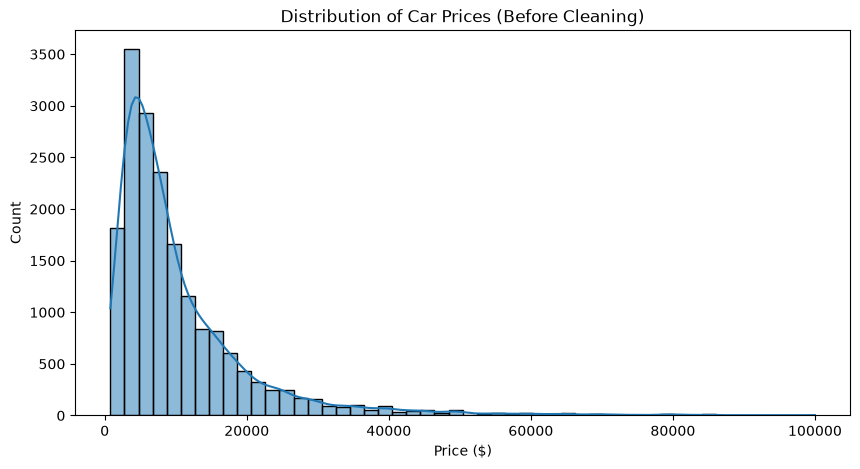

In [ ]:
# Plot price distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (Before Cleaning)')
plt.xlabel('Price ($)')
plt.show()

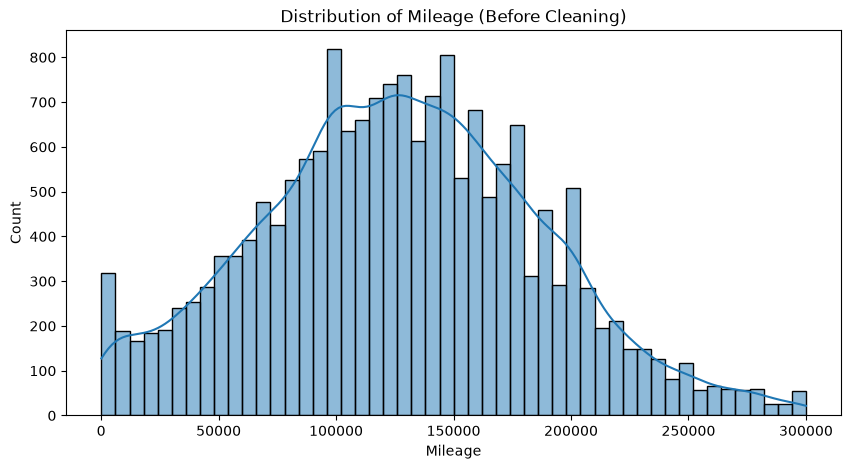

In [ ]:
# Plot Mileage distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (Before Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [ ]:
# Define realistic bounds for market vehicles
MIN_PRICE = 800
MAX_PRICE = 100000
MIN_MILEAGE = 100
MAX_MILEAGE = 300000

# Filter outliers and drop rows missing absolute core requirements
df_clean = df[
    (df['price'] >= MIN_PRICE) & 
    (df['price'] <= MAX_PRICE) &
    (df['mileage'] >= MIN_MILEAGE) & 
    (df['mileage'] <= MAX_MILEAGE) &
    (df['name'].notna())
].copy()

# Extract Year and calculate Age
df_clean['year'] = df_clean['name'].astype(str).str.extract(r'(\b(19[0-9]{2}|20[0-2][0-9])\b)')[0]
df_clean = df_clean.dropna(subset=['year'])
df_clean['year'] = df_clean['year'].astype(int)

current_year = datetime.datetime.now().year
df_clean['age'] = current_year - df_clean['year']

# Standardize location string
df_clean['location'] = df_clean['location'].astype(str).str.split('/').str[0].str.lower().str.strip()

print(f"Rows after cleaning: {len(df_clean)}")

Rows after cleaning: 18186


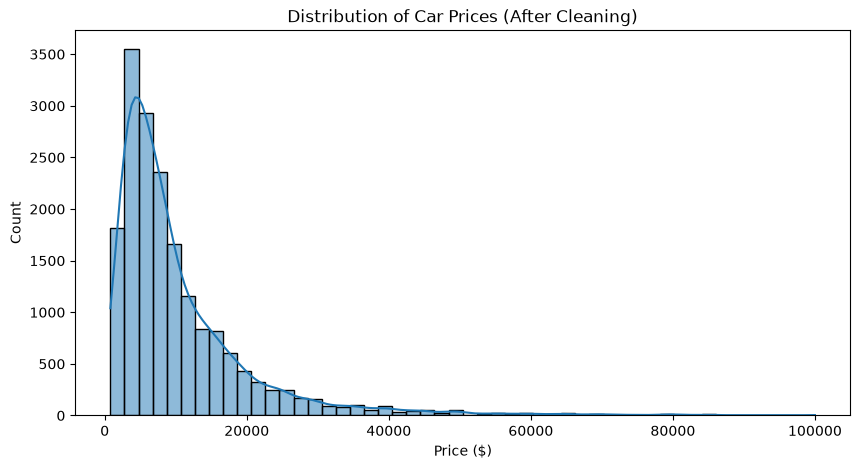

In [ ]:
# Plot price distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (After Cleaning)')
plt.xlabel('Price ($)')
plt.show()

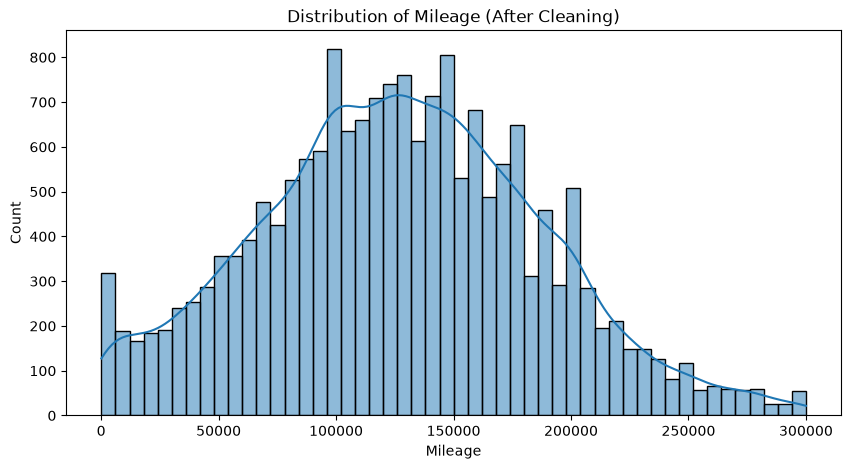

In [ ]:
# Plot Mileage distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (After Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [ ]:
import re

# Extract Year (Looks for 19xx or 20xx)
df_clean['year'] = df_clean['name'].str.extract(r'(\b(19[0-9]{2}|20[0-2][0-9])\b)')[0]

# Drop rows that didn't have a year in the title
df_clean = df_clean.dropna(subset=['year'])
df_clean['year'] = df_clean['year'].astype(int)

df_clean

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim,region
0,2021 Audi I Q5 Plug-In Hybrid,https://www.craigslist.org/view/d/orinda-2021-...,28800,67000.0,lafayette,Audi,2021,Q5,5,23685.80,-5114.207031,excellent,clean,Other,other
1,2005 Volvo S40 – 117K Miles,https://www.craigslist.org/view/d/oakland-2005...,3900,118000.0,alameda,Volvo,2005,S40,21,5253.68,1353.682617,good,salvage,Base,other
2,1966 Chevy El Camino Clean Title No Rust Read ...,https://www.craigslist.org/view/d/san-jose-196...,9300,66000.0,sanjoseeast,Chevrolet,1966,El Camino,60,26773.10,17473.134766,unspecified,clean,Base,other
3,2016 Toyota Corolla Sport,https://www.craigslist.org/view/d/sebastopol-2...,12000,144000.0,sebastopol,Toyota,2016,Corolla,10,9351.89,-2648.109375,excellent,clean,Sport,other
4,2005 Ford E250 Econoline White Van,https://www.craigslist.org/view/d/hayward-2005...,8000,118000.0,hayward,Ford,2005,E250 Econoline,21,5738.81,-2261.187988,good,clean,Other,sfbay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18181,"2008 Chevy Impala Lt 3.5L V6 - Runs Great, 240...",https://www.craigslist.org/view/d/santa-cruz-2...,2000,240000.0,santa cruz,NaN,2008,NaN,18,3454.18,1454.175781,good,clean,NaN,other
18182,2025 Ford Maverick Xl All Wheel Drive,https://www.craigslist.org/view/d/south-gate-2...,23995,1788.0,south gate,NaN,2025,NaN,1,27291.80,3296.843750,excellent,salvage,NaN,other
18183,"2018 Ford Focus Se - $4,000 (Simi Valley)",https://www.craigslist.org/view/d/simi-valley-...,4000,83000.0,simi valley,NaN,2018,NaN,8,8060.53,4060.527832,good,clean,NaN,other
18184,1937 Chevy Master Deluxe Coupe,https://www.craigslist.org/view/d/porterville-...,45000,50000.0,porterville,NaN,1937,NaN,89,27939.20,-17060.787109,excellent,clean,NaN,other


In [ ]:
import datetime

# Get the current year
current_year = datetime.datetime.now().year

# Calculate age
df_clean['age'] = current_year - df_clean['year']

# Quick check
print(df_clean[['name', 'year', 'age']].head())

                                                name  year  age
0                      2021 Audi I Q5 Plug-In Hybrid  2021    5
1                        2005 Volvo S40 – 117K Miles  2005   21
2  1966 Chevy El Camino Clean Title No Rust Read ...  1966   60
3                          2016 Toyota Corolla Sport  2016   10
4                 2005 Ford E250 Econoline White Van  2005   21


In [ ]:
df_clean.to_csv('../data/clean_listings.csv', index=False)

# Model Training & Evaluation

* Split data into Train (80%) and Test (20%).
* Apply One-Hot Encoding to categorical data (Make, Location).
* Train an XGBoost Regression model.

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Initialize local HuggingFace embedding model
print("Loading SentenceTransformer model...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for the 'name' column
print("Generating title embeddings...")
title_embeddings = embed_model.encode(df_clean['name'].tolist(), show_progress_bar=True)

# Convert embeddings to DataFrame
embed_df = pd.DataFrame(title_embeddings, index=df_clean.index)
embed_df.columns = [f"embed_{i}" for i in range(embed_df.shape[1])]

del embed_model

Loading SentenceTransformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6713.49it/s]


Generating title embeddings...


Batches: 100%|██████████| 569/569 [00:10<00:00, 52.12it/s]


In [ ]:
# One-Hot Encode remaining categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_features = ['condition', 'title_status']

cat_encoded = ohe.fit_transform(df_clean[cat_features])
cat_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(), index=df_clean.index)

# Isolate numerical features
num_df = df_clean[['age', 'mileage']].copy()

# Construct final feature matrix (X) and target (y)
X = pd.concat([num_df, cat_df, embed_df], axis=1)
y = df_clean['price']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training matrix shape: {X_train.shape}")
print(f"Testing matrix shape: {X_test.shape}")

Training matrix shape: (14548, 402)
Testing matrix shape: (3638, 402)


: 

## Train the Model

In [ ]:
# Initialize and train XGBoost Regressor
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training model...")
model.fit(X_train, y_train)
print("Training complete.")

In [ ]:
# Generate predictions
predictions = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model Performance:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-Squared (R2): {r2:.2f}")

# Sample comparison
comparison = pd.DataFrame({
    'Actual_Price': y_test.values[:10],
    'Predicted_Price': predictions[:10].astype(int),
    'Age': X_test['age'].values[:10],
    'Mileage': X_test['mileage'].values[:10],
    'Title': df_clean.loc[X_test.index[:10], 'name'].values
})
print("\nSample Predictions vs Actuals:")
print(comparison)

# Export the model using Pickle

In [ ]:
import joblib
import os

os.makedirs('../api', exist_ok=True)

# Save the XGBoost model
joblib.dump(model, '../api/model.pkl')

# Save the One-Hot Encoder
joblib.dump(ohe, '../api/ohe.pkl')

# Save the list of model columns for future reference
joblib.dump(X_train.columns.tolist(), '../api/model_columns.pkl')

# Save the sentence transformer model
# embed_model.save('../api/sentence_transformer_model')

print("Artifacts saved successfully: model.pkl, ohe.pkl, model_columns.pkl, sentence_transformer_model/")